# Age-Responsive Asset Allocation Optimization

This notebook implements an optimization framework for age-responsive asset allocation between stocks and bonds.

Key features:
- Age-based allocation glide path (stocks vs bonds)
- Minimum consumption floor that decreases 2% per year in real terms
- Spending policy: max(min_consumption, percentage_of_wealth)
- **Cost function: Negative log consumption utility** (simple baseline)
- 3% inflation rate

## Approach

We optimize asset allocation to maximize expected log consumption utility - a standard economic objective that provides diminishing marginal utility of consumption.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.optimize import minimize

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Return Simulation

In [2]:
# Load historical returns
try:
    from sallypy.repos import TimeSeriesRepo
    ts_repo = TimeSeriesRepo()
    returns = ts_repo.get_monthly_returns(["BMK0017", "BMK0188"])
    returns.columns = ["Bonds", "Stocks"]
    returns.dropna(inplace=True)
    yearly_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
except:
    # Fallback to CSV if sallypy not available
    print("Loading from CSV...")
    returns = pd.read_csv("../WIP/returns.csv", index_col=0, parse_dates=True)
    yearly_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)

yearly_cov = yearly_returns.cov()
yearly_mean = yearly_returns.mean()

print(f"Mean annual returns:\n{yearly_mean}")
print(f"\nCovariance matrix:\n{yearly_cov}")

Mean annual returns:
Bonds     0.076926
Stocks    0.112436
dtype: float64

Covariance matrix:
           Bonds    Stocks
Bonds   0.003535  0.000413
Stocks  0.000413  0.041097


In [3]:
def cholesky_bootstrap_returns(n: int, s: int, cov: pd.DataFrame, exp_ret: pd.DataFrame) -> np.ndarray:
    """
    Simulate returns using the Cholesky decomposition of the covariance matrix.
    
    Parameters
    ----------
    n : int
        Number of simulations.
    s : int
        Length of the simulation (number of time steps).
    cov : pd.DataFrame
        Covariance matrix.
    exp_ret : pd.DataFrame
        Expected returns.
    
    Returns
    -------
    np.ndarray
        n x s x num_assets tensor of simulated returns.
    """
    rng = np.random.default_rng()
    y = rng.multivariate_normal(exp_ret.values.flatten(), cov.values, size=(n, s))
    return y

## 2. Wealth Simulation with Consumption Policy

In [4]:
def calculate_consumption(wealth: torch.Tensor, 
                         time_step: int,
                         min_consumption_real: float,
                         consumption_rate: float,
                         inflation: float = 0.03,
                         real_decline_rate: float = 0.02) -> torch.Tensor:
    """
    Calculate consumption at a given time step.
    
    Consumption is the maximum of:
    - Minimum consumption (adjusted for inflation and real decline)
    - Percentage of current wealth
    
    Parameters
    ----------
    wealth : torch.Tensor
        Current wealth for all simulations (n,)
    time_step : int
        Current time step (years from start)
    min_consumption_real : float
        Minimum consumption in real terms at year 0
    consumption_rate : float
        Percentage of wealth to consume (e.g., 0.04 for 4%)
    inflation : float
        Annual inflation rate (default: 0.03 for 3%)
    real_decline_rate : float
        Annual decline in real consumption needs (default: 0.02 for 2%)
    
    Returns
    -------
    torch.Tensor
        Consumption amount for all simulations (n,)
    """
    # Adjust min consumption for real decline and inflation
    # Real terms: decline by 2% per year
    # Nominal terms: adjust for inflation
    real_min_consumption = min_consumption_real * ((1 - real_decline_rate) ** time_step)
    nominal_min_consumption = real_min_consumption * ((1 + inflation) ** time_step)
    
    # Percentage-based consumption
    percentage_consumption = wealth * consumption_rate
    
    # Take maximum of the two
    consumption = torch.maximum(
        torch.full_like(wealth, nominal_min_consumption),
        percentage_consumption
    )
    
    # Cannot consume more than available wealth
    consumption = torch.minimum(consumption, wealth)
    
    return consumption

In [5]:
def simulate_wealth_with_consumption(
    simulated_returns: torch.Tensor,
    stock_weights: torch.Tensor,
    initial_wealth: float,
    min_consumption_real: float,
    consumption_rate: float,
    inflation: float = 0.03,
    real_decline_rate: float = 0.02,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Simulate wealth trajectories with consumption policy.
    
    Parameters
    ----------
    simulated_returns : torch.Tensor
        n x s x 2 tensor of simulated returns [bonds, stocks]
    stock_weights : torch.Tensor
        s tensor of stock allocation at each time step
    initial_wealth : float
        Starting wealth
    min_consumption_real : float
        Minimum consumption in real terms at year 0
    consumption_rate : float
        Percentage of wealth to consume
    inflation : float
        Annual inflation rate
    real_decline_rate : float
        Annual decline in real consumption needs
    
    Returns
    -------
    tuple[torch.Tensor, torch.Tensor]
        (wealth, consumption) - Both as n x (s+1) and n x s tensors
    """
    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    
    wealth_steps = []
    consumption_steps = []
    
    # Initialize wealth
    wealth_t = torch.full((n,), initial_wealth, 
                         dtype=simulated_returns.dtype, 
                         device=simulated_returns.device)
    wealth_steps.append(wealth_t)
    
    for i in range(s):
        # Calculate consumption for this period
        consumption_t = calculate_consumption(
            wealth_t, i, min_consumption_real, consumption_rate, 
            inflation, real_decline_rate
        )
        consumption_steps.append(consumption_t)
        
        # Withdraw consumption
        wealth_after_consumption = wealth_t - consumption_t
        
        # Calculate portfolio weights
        stock_weight = stock_weights[i]
        bond_weight = 1 - stock_weight
        
        # Apply returns
        bond_return = simulated_returns[:, i, 0]
        stock_return = simulated_returns[:, i, 1]
        
        portfolio_return = bond_weight * (1 + bond_return) + stock_weight * (1 + stock_return)
        
        # Update wealth
        next_wealth = wealth_after_consumption * portfolio_return
        
        # Ensure non-negative wealth
        next_wealth = torch.maximum(next_wealth, torch.zeros_like(next_wealth))
        
        wealth_steps.append(next_wealth)
        wealth_t = next_wealth
    
    wealth = torch.stack(wealth_steps, dim=1)
    consumption = torch.stack(consumption_steps, dim=1)
    
    return wealth, consumption

## 3. Cost Function

In [6]:
def log_consumption_utility(
    consumption: torch.Tensor,
) -> torch.Tensor:
    """
    Calculate negative log utility of consumption (we minimize cost = -utility).
    
    The log utility function is standard in economics and provides diminishing 
    marginal utility of consumption.
    
    Parameters
    ----------
    consumption : torch.Tensor
        n x s tensor of consumption values
    
    Returns
    -------
    torch.Tensor
        Scalar cost value (negative of mean log consumption)
    """
    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    consumption_safe = torch.maximum(consumption, torch.tensor(epsilon, device=consumption.device))
    
    # Calculate log utility for each consumption value
    log_utility = torch.log(consumption_safe)
    
    # Return negative mean utility (we want to minimize cost = maximize utility)
    return -log_utility.mean()


def allocation_smoothness_penalty(
    stock_weights: torch.Tensor,
    weight: float = 0.01,
) -> torch.Tensor:
    """
    Penalize large changes in allocation between time steps.
    
    Parameters
    ----------
    stock_weights : torch.Tensor
        s tensor of stock allocations
    weight : float
        Weight of this penalty
    
    Returns
    -------
    torch.Tensor
        Scalar penalty value
    """
    differences = stock_weights[1:] - stock_weights[:-1]
    return weight * (differences ** 2).sum()


def total_cost(
    consumption: torch.Tensor,
    stock_weights: torch.Tensor,
    smoothness_weight: float = 0.01,
) -> torch.Tensor:
    """
    Calculate total cost: negative log consumption utility + smoothness penalty.
    """
    # Main objective: maximize log consumption utility (minimize negative utility)
    cost = log_consumption_utility(consumption)
    
    # Penalty for non-smooth allocations
    cost = cost + allocation_smoothness_penalty(stock_weights, smoothness_weight)
    
    return cost

## 4. Interpolation Function

We use bilinear interpolation to create a smooth glide path from a small number of policy nodes.

In [7]:
def interpolate_policy(policy_nodes: torch.Tensor, n_timesteps: int) -> torch.Tensor:
    """
    Interpolate policy nodes to create a smooth allocation path.
    
    Uses linear interpolation between nodes.
    
    Parameters
    ----------
    policy_nodes : torch.Tensor
        Tensor of policy values at key timesteps (n_nodes,)
    n_timesteps : int
        Number of timesteps to interpolate to
    
    Returns
    -------
    torch.Tensor
        Interpolated policy values (n_timesteps,)
    """
    n_nodes = len(policy_nodes)
    
    # Create node positions evenly spaced across the timeline
    node_positions = torch.linspace(0, n_timesteps - 1, n_nodes, device=policy_nodes.device)
    
    # Create target positions for all timesteps
    target_positions = torch.arange(n_timesteps, dtype=torch.float32, device=policy_nodes.device)
    
    # Perform linear interpolation
    # For each target position, find the two surrounding nodes and interpolate
    interpolated = torch.zeros(n_timesteps, dtype=policy_nodes.dtype, device=policy_nodes.device)
    
    for i, target_pos in enumerate(target_positions):
        # Find the two surrounding nodes
        # Use searchsorted to find where to insert target_pos
        right_idx = torch.searchsorted(node_positions, target_pos, right=True)
        
        if right_idx == 0:
            # Before first node - use first node value
            interpolated[i] = policy_nodes[0]
        elif right_idx >= n_nodes:
            # After last node - use last node value
            interpolated[i] = policy_nodes[-1]
        else:
            # Between two nodes - linear interpolation
            left_idx = right_idx - 1
            
            left_pos = node_positions[left_idx]
            right_pos = node_positions[right_idx]
            
            # Interpolation weight
            weight = (target_pos - left_pos) / (right_pos - left_pos)
            
            interpolated[i] = (1 - weight) * policy_nodes[left_idx] + weight * policy_nodes[right_idx]
    
    return interpolated

## 5. Optimization Setup

In [8]:
# Simulation parameters
N_SIMULATIONS = 100000  # Number of Monte Carlo simulations
BATCHES = 10  # Number of batches to split simulations into (for memory management)
S_TIMESTEPS = 40       # Number of years to simulate
INITIAL_WEALTH = 500000  # Starting wealth

# Policy parameters
N_POLICY_NODES = 5  # Number of policy nodes to optimize

# Consumption parameters
MIN_CONSUMPTION_REAL = 30000  # Minimum consumption in today's dollars
CONSUMPTION_RATE = 0.04      # 4% of wealth per year
INFLATION = 0.03              # 3% annual inflation
REAL_DECLINE_RATE = 0.02      # 2% decline in real needs per year

# Cost function parameters
SMOOTHNESS_WEIGHT = 0.01     # Penalty for allocation changes (applied to nodes)


# PyTorch device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


In [9]:
# Generate simulated returns
mc_returns = torch.tensor(
    cholesky_bootstrap_returns(
        n=N_SIMULATIONS*BATCHES,
        s=S_TIMESTEPS,
        cov=yearly_cov,
        exp_ret=yearly_mean,
    ),
    dtype=torch.float32,
    device=DEVICE
)

print(f"Simulated returns shape: {mc_returns.shape}")
print(f"Mean bond return: {mc_returns[:, :, 0].mean():.4f}")
print(f"Mean stock return: {mc_returns[:, :, 1].mean():.4f}")

Simulated returns shape: torch.Size([1000000, 40, 2])
Mean bond return: 0.0769
Mean stock return: 0.1124


In [10]:
# Initialize policy nodes (will be interpolated to full timeline)
# Start with high equity allocation, can be optimized
policy_nodes = torch.tensor(
    np.linspace(0.9, 0.9, N_POLICY_NODES),  # Start with 90% stocks across all nodes
    dtype=torch.float32,
    requires_grad=True,
    device=DEVICE
)

# Test interpolation
test_interpolated = interpolate_policy(policy_nodes, S_TIMESTEPS)

print(f"Policy configuration:")
print(f"  Number of policy nodes: {N_POLICY_NODES}")
print(f"  Interpolated to {S_TIMESTEPS} timesteps")
print(f"  Node positions (years): {np.linspace(0, S_TIMESTEPS-1, N_POLICY_NODES).astype(int)}")
print(f"\nInitial node values (stock allocation):")
for i, node_val in enumerate(policy_nodes.detach().cpu().numpy()):
    year = int(np.linspace(0, S_TIMESTEPS-1, N_POLICY_NODES)[i])
    print(f"  Node {i+1} (year {year}): {node_val:.1%}")
print(f"\nInterpolated path:")
print(f"  Start (year 0): {test_interpolated[0].item():.1%}")
print(f"  End (year {S_TIMESTEPS-1}): {test_interpolated[-1].item():.1%}")

Policy configuration:
  Number of policy nodes: 5
  Interpolated to 40 timesteps
  Node positions (years): [ 0  9 19 29 39]

Initial node values (stock allocation):
  Node 1 (year 0): 90.0%
  Node 2 (year 9): 90.0%
  Node 3 (year 19): 90.0%
  Node 4 (year 29): 90.0%
  Node 5 (year 39): 90.0%

Interpolated path:
  Start (year 0): 90.0%
  End (year 39): 90.0%


## 6. Optimization Loop

In [11]:
# Setup optimizer - now optimizing policy nodes instead of full timeline
optimizer = torch.optim.Adam([policy_nodes], lr=0.005)

# Track optimization progress
cost_history = []
policy_history = []  # Will store interpolated policies for visualization
policy_nodes_history = []  # Will store the actual optimized nodes
shortfall_prob_history = []
lr_history = []

# Adaptive learning rate parameters
initial_lr = 0.005
JUMP_THRESHOLD = 0.05
prev_cost = None

N_ITERATIONS = 2000

print("Starting optimization...\n")

for iteration in range(N_ITERATIONS):

    optimizer.zero_grad()
    
    # Interpolate policy nodes to full timeline
    stock_weights = interpolate_policy(policy_nodes, S_TIMESTEPS)

    batch_no = iteration % BATCHES  # Use different batches of returns for each iteration
    # Simulate wealth and consumption
    wealth, consumption = simulate_wealth_with_consumption(
        simulated_returns=mc_returns[batch_no*N_SIMULATIONS:(batch_no+1)*N_SIMULATIONS],
        stock_weights=stock_weights,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        inflation=INFLATION,
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    # Calculate cost (log consumption utility + smoothness penalty on nodes)
    cost = total_cost(
        consumption=consumption,
        stock_weights=policy_nodes,  # Apply smoothness penalty to nodes, not interpolated values
        smoothness_weight=SMOOTHNESS_WEIGHT,
    )
    
    # Backward pass
    cost.backward()
    
    # Update weights
    optimizer.step()
    
    # Clamp policy nodes to [0, 1]
    with torch.no_grad():
        policy_nodes.clamp_(0.0, 1.0)
    
    # Adaptive learning rate
    if prev_cost is not None:
        cost_increase = cost.item() - prev_cost
        if cost_increase > JUMP_THRESHOLD:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.5
    prev_cost = cost.item()
    
    # Track metrics
    cost_history.append(cost.item())
    policy_history.append(stock_weights.detach().cpu().numpy().copy())
    policy_nodes_history.append(policy_nodes.detach().cpu().numpy().copy())
    lr_history.append(optimizer.param_groups[0]['lr'])
    
    # Calculate shortfall probability (for monitoring only)
    with torch.no_grad():
        shortfalls = 0
        for t in range(S_TIMESTEPS):
            real_min = MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t)
            nominal_min = real_min * ((1 + INFLATION) ** t)
            shortfalls += (consumption[:, t] < nominal_min).sum().item()
        shortfall_prob = shortfalls / (N_SIMULATIONS * S_TIMESTEPS)
        shortfall_prob_history.append(shortfall_prob)
    
    # Print progress
    if (iteration + 1) % 50 == 0:
        print(f"Iteration {iteration + 1}/{N_ITERATIONS}")
        print(f"  Cost: {cost.item():.6f}")
        print(f"  Mean log consumption: {-cost.item():.6f}")
        print(f"  Shortfall probability: {shortfall_prob:.2%}")
        print(f"  Mean consumption: ${consumption.mean().item():,.0f}")
        print(f"  Mean terminal wealth: ${wealth[:, -1].mean().item():,.0f}")
        print(f"  Bankruptcy rate: {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
        print(f"  Learning rate: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"  Policy nodes: [{', '.join([f'{n:.1%}' for n in policy_nodes.detach().cpu().numpy()])}]")
        print()

print("\nOptimization complete!")

Starting optimization...

Iteration 50/2000
  Cost: -8.591818
  Mean log consumption: 8.591818
  Shortfall probability: 8.34%
  Mean consumption: $66,092
  Mean terminal wealth: $3,939,342
  Bankruptcy rate: 22.37%
  Learning rate: 0.005000
  Policy nodes: [68.3%, 66.9%, 82.9%, 85.6%, 90.0%]

Iteration 100/2000
  Cost: -9.236311
  Mean log consumption: 9.236311
  Shortfall probability: 5.85%
  Mean consumption: $60,316
  Mean terminal wealth: $3,468,836
  Bankruptcy rate: 18.26%
  Learning rate: 0.005000
  Policy nodes: [52.8%, 50.0%, 75.8%, 83.4%, 90.5%]

Iteration 150/2000
  Cost: -9.634527
  Mean log consumption: 9.634527
  Shortfall probability: 4.29%
  Mean consumption: $56,855
  Mean terminal wealth: $3,174,674
  Bankruptcy rate: 15.47%
  Learning rate: 0.005000
  Policy nodes: [35.0%, 45.4%, 71.3%, 82.1%, 88.2%]

Iteration 200/2000
  Cost: -9.810604
  Mean log consumption: 9.810604
  Shortfall probability: 3.53%
  Mean consumption: $53,605
  Mean terminal wealth: $2,910,368
  Ba

## 7. Results Visualization

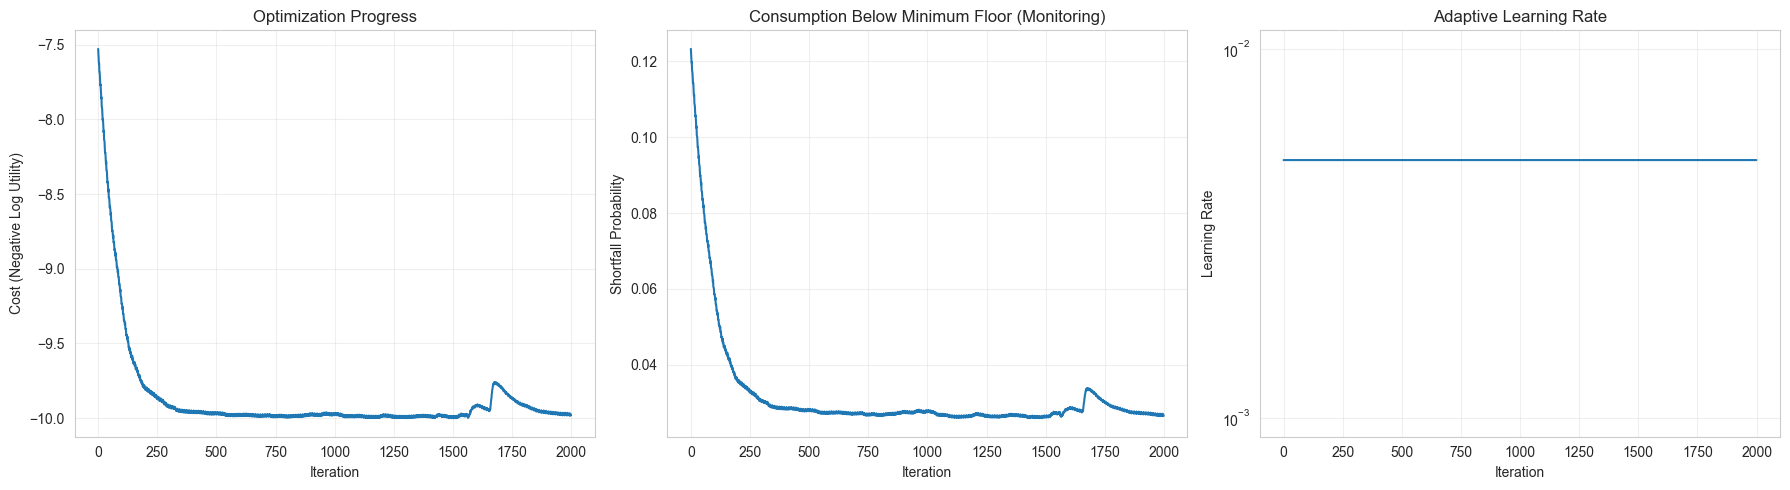

In [12]:
# Plot optimization progress
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cost_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (Negative Log Utility)')
axes[0].set_title('Optimization Progress')
axes[0].grid(True, alpha=0.3)

axes[1].plot(shortfall_prob_history)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Shortfall Probability')
axes[1].set_title('Consumption Below Minimum Floor (Monitoring)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lr_history)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Adaptive Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

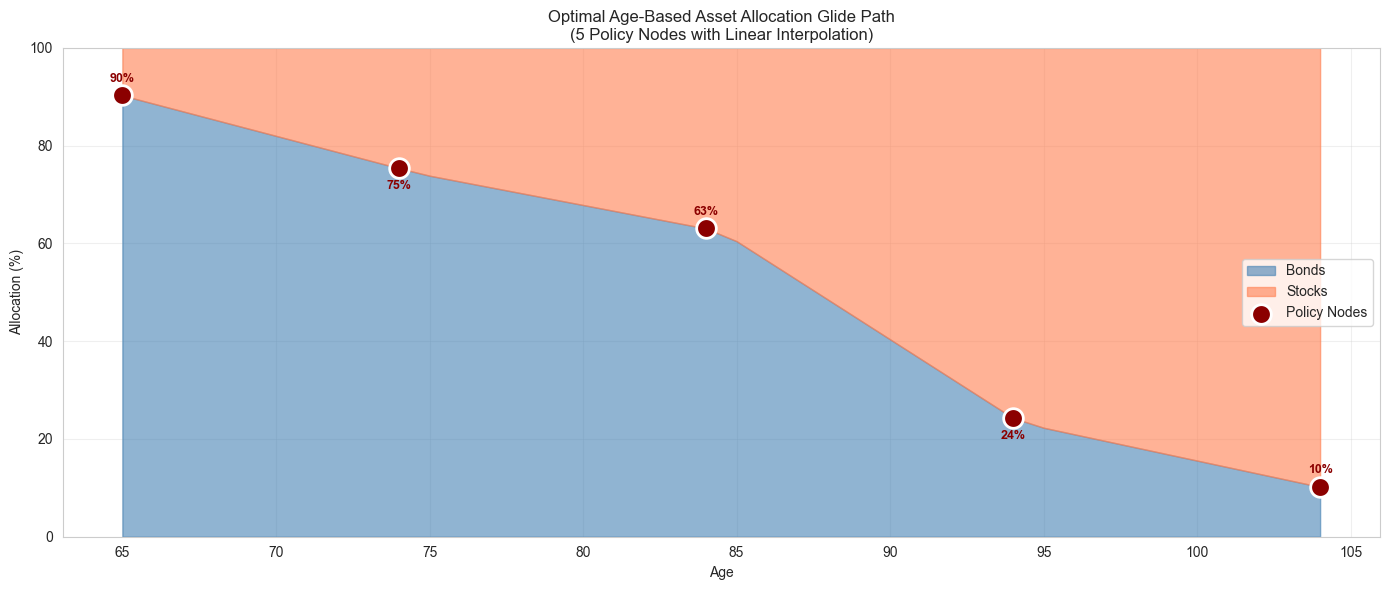


Optimal Policy Nodes:
  Node 1 (Age 65): 9.7% stocks
  Node 2 (Age 74): 25.8% stocks
  Node 3 (Age 84): 37.5% stocks
  Node 4 (Age 94): 76.7% stocks
  Node 5 (Age 104): 89.8% stocks

Interpolated Path:
  Age 65: 9.7% stocks
  Age 104: 89.8% stocks
  Average: 47.5% stocks


In [16]:
# Plot optimal allocation glide path with policy nodes
ages = np.arange(65, 65 + S_TIMESTEPS)

# Get final optimized interpolated weights
with torch.no_grad():
    final_stock_weights = interpolate_policy(policy_nodes, S_TIMESTEPS).cpu().numpy()
    final_bond_weights = 1 - final_stock_weights
    final_nodes = policy_nodes.cpu().numpy()

# Node positions in years
node_years = np.linspace(0, S_TIMESTEPS - 1, N_POLICY_NODES).astype(int)
node_ages = 65 + node_years

plt.figure(figsize=(14, 6))

# Plot interpolated path
plt.fill_between(ages, 0, final_bond_weights * 100, alpha=0.6, label='Bonds', color='steelblue')
plt.fill_between(ages, final_bond_weights * 100, 100, alpha=0.6, label='Stocks', color='coral')

# Mark policy nodes
stock_at_nodes = final_stock_weights[node_years] * 100
plt.scatter(node_ages, 100 - stock_at_nodes, s=200, c='darkred', marker='o', 
           label='Policy Nodes', zorder=5, edgecolors='white', linewidths=2)

# Add text labels for nodes
for i, (age, stock_pct) in enumerate(zip(node_ages, stock_at_nodes)):
    plt.annotate(f'{100 - stock_pct:.0f}%', 
                xy=(age, 100 - stock_pct), 
                xytext=(0, 10 if i % 2 == 0 else -15),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                fontweight='bold',
                color='darkred')

plt.xlabel('Age')
plt.ylabel('Allocation (%)')
plt.title(f'Optimal Age-Based Asset Allocation Glide Path\n({N_POLICY_NODES} Policy Nodes with Linear Interpolation)')
plt.legend(loc='right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"\nOptimal Policy Nodes:")
for i, (age, stock_pct) in enumerate(zip(node_ages, final_nodes)):
    print(f"  Node {i+1} (Age {age}): {stock_pct:.1%} stocks")

print(f"\nInterpolated Path:")
print(f"  Age 65: {final_stock_weights[0]:.1%} stocks")
print(f"  Age {65 + S_TIMESTEPS - 1}: {final_stock_weights[-1]:.1%} stocks")
print(f"  Average: {final_stock_weights.mean():.1%} stocks")

Creating GIF... (this may take a moment)
GIF saved as 'optimization_progress.gif'
Total frames: 200


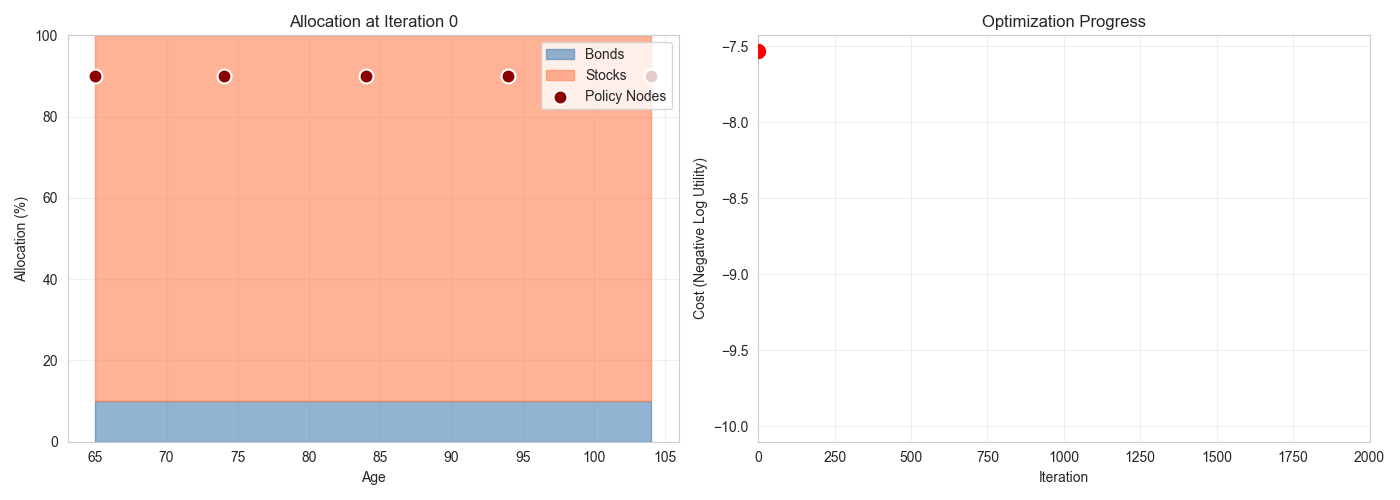

In [ ]:
# Create animated GIF of policy evolution
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# Sample every N iterations to keep GIF size reasonable
sample_rate = 10
sampled_iterations = range(0, len(policy_history), sample_rate)
sampled_policies = [policy_history[i] for i in sampled_iterations]
sampled_nodes = [policy_nodes_history[i] for i in sampled_iterations]
sampled_costs = [cost_history[i] for i in sampled_iterations]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def update(frame):
    axes[0].clear()
    axes[1].clear()
    
    # Left panel: Allocation glide path at this iteration
    policy = sampled_policies[frame]
    nodes = sampled_nodes[frame]
    bond_weights = 1 - policy
    
    axes[0].fill_between(ages, 0, bond_weights * 100, alpha=0.6, label='Bonds', color='steelblue')
    axes[0].fill_between(ages, bond_weights * 100, 100, alpha=0.6, label='Stocks', color='coral')
    
    # Mark policy nodes
    stock_at_nodes = policy[node_years] * 100
    axes[0].scatter(node_ages, 100 - stock_at_nodes, s=100, c='darkred', marker='o', 
                   label='Policy Nodes', zorder=5, edgecolors='white', linewidths=1.5)
    
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Allocation (%)')
    axes[0].set_title(f'Allocation at Iteration {sampled_iterations[frame]}')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 100)
    
    # Right panel: Cost history up to this iteration
    current_iter = sampled_iterations[frame]
    axes[1].plot(range(current_iter + 1), cost_history[:current_iter + 1], 'b-', linewidth=1.5)
    axes[1].scatter(current_iter, sampled_costs[frame], color='red', s=100, zorder=5)
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Cost (Negative Log Utility)')
    axes[1].set_title('Optimization Progress')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, len(cost_history))
    axes[1].set_ylim(min(cost_history) - 0.1, max(cost_history) + 0.1)
    
    plt.tight_layout()

# Create animation
anim = FuncAnimation(fig, update, frames=len(sampled_policies), interval=100, repeat=True)

# Save as GIF
print("Creating GIF... (this may take a moment)")
writer = PillowWriter(fps=10)
anim.save('optimization_progress.gif', writer=writer, dpi=100)
plt.close()

print("GIF saved as 'optimization_progress.gif'")
print(f"Total frames: {len(sampled_policies)}")

# Display the GIF
Image(filename='optimization_progress.gif')

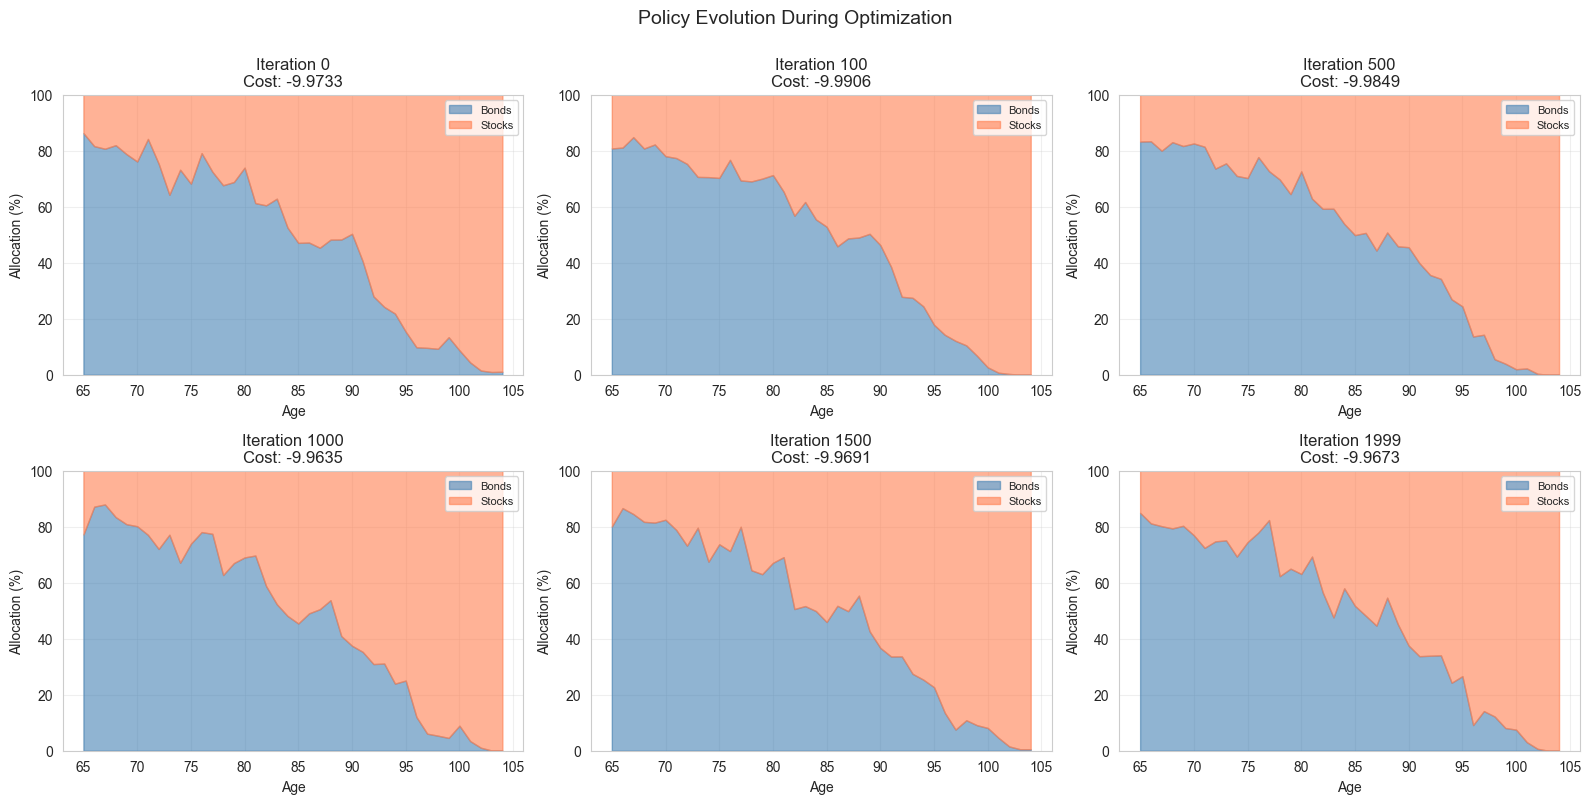

In [ ]:
# Alternative: Static view of policy evolution at key iterations
key_iterations = [0, 100, 500, 1000, 1500, len(policy_history)-1]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, iter_num in enumerate(key_iterations):
    policy = policy_history[iter_num]
    nodes = policy_nodes_history[iter_num]
    bond_weights = (1 - policy) * 100
    stock_weights_pct = policy * 100
    
    # Plot interpolated path
    axes[idx].fill_between(ages, 0, bond_weights, alpha=0.6, label='Bonds', color='steelblue')
    axes[idx].fill_between(ages, bond_weights, 100, alpha=0.6, label='Stocks', color='coral')
    
    # Mark policy nodes
    stock_at_nodes = stock_weights_pct[node_years]
    axes[idx].scatter(node_ages, stock_at_nodes, s=100, c='darkred', marker='o', 
                     label='Nodes', zorder=5, edgecolors='white', linewidths=1.5)
    
    axes[idx].set_xlabel('Age')
    axes[idx].set_ylabel('Allocation (%)')
    axes[idx].set_title(f'Iteration {iter_num}\nCost: {cost_history[iter_num]:.4f}')
    axes[idx].legend(loc='upper right', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0, 100)

plt.suptitle('Policy Evolution During Optimization', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# Run final simulation with optimal weights
with torch.no_grad():
    # Interpolate final policy
    final_stock_weights = interpolate_policy(policy_nodes, S_TIMESTEPS)
    
    wealth_final, consumption_final = simulate_wealth_with_consumption(
        simulated_returns=mc_returns,
        stock_weights=final_stock_weights,
        initial_wealth=INITIAL_WEALTH,
        min_consumption_real=MIN_CONSUMPTION_REAL,
        consumption_rate=CONSUMPTION_RATE,
        inflation=INFLATION,
        real_decline_rate=REAL_DECLINE_RATE,
    )
    
    wealth_final_np = wealth_final.cpu().numpy()
    consumption_final_np = consumption_final.cpu().numpy()

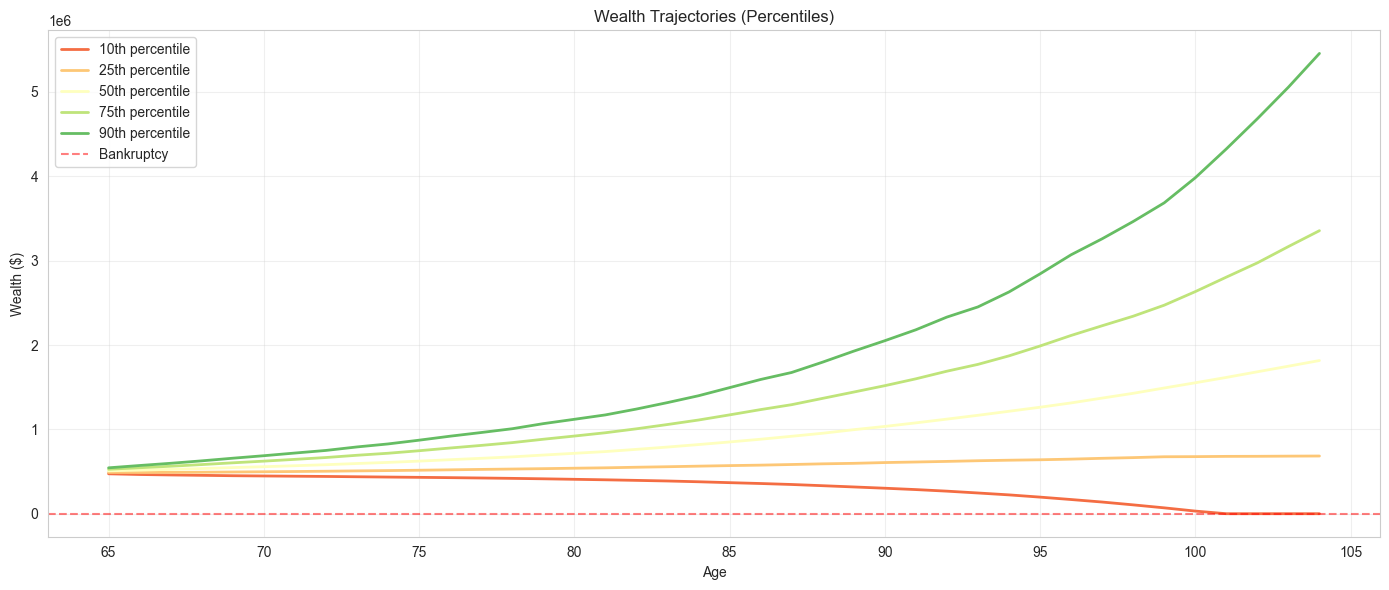

In [81]:
# Plot wealth trajectories
plt.figure(figsize=(14, 6))

# Plot percentiles
percentiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(percentiles)))

for i, p in enumerate(percentiles):
    plt.plot(ages, np.percentile(wealth_final_np[:, 1:], p, axis=0), 
             label=f'{p}th percentile', linewidth=2, color=colors[i])

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Bankruptcy')
plt.xlabel('Age')
plt.ylabel('Wealth ($)')
plt.title('Wealth Trajectories (Percentiles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

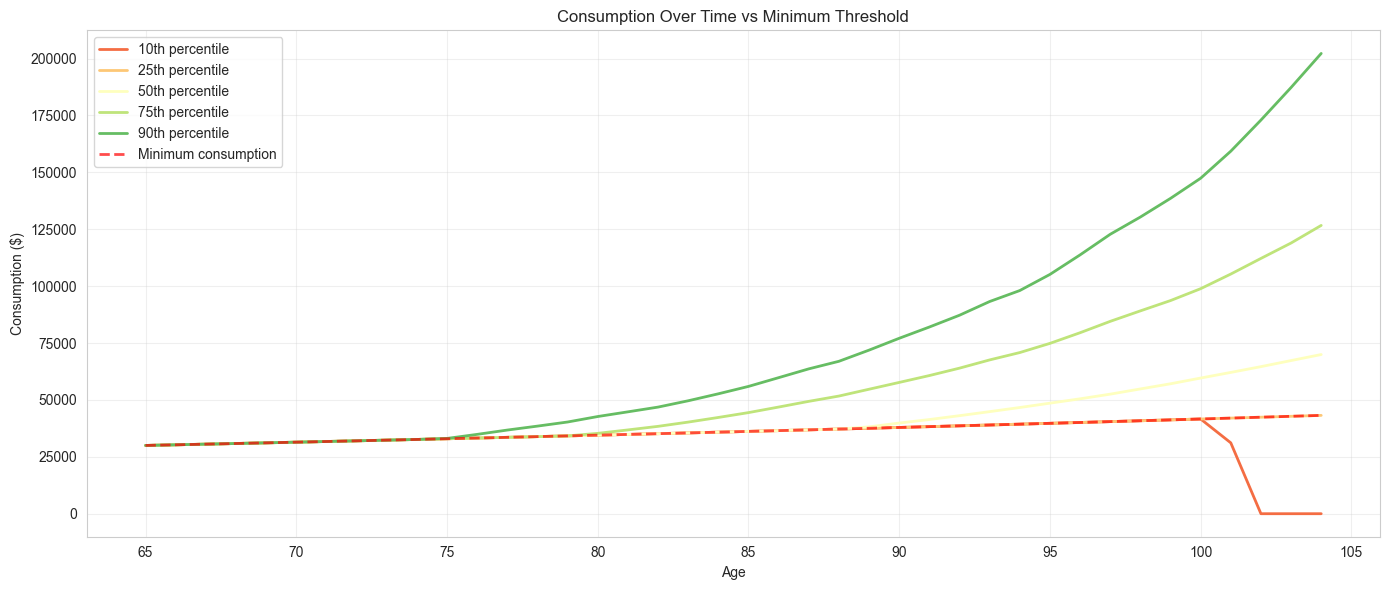

In [82]:
# Plot consumption vs minimum threshold
plt.figure(figsize=(14, 6))

# Calculate minimum consumption nominal values over time
min_consumption_nominal = np.array([
    MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t) * ((1 + INFLATION) ** t)
    for t in range(S_TIMESTEPS)
])

# Plot consumption percentiles
for i, p in enumerate([10, 25, 50, 75, 90]):
    plt.plot(ages, np.percentile(consumption_final_np, p, axis=0),
             label=f'{p}th percentile', linewidth=2, color=colors[i])

# Plot minimum consumption threshold
plt.plot(ages, min_consumption_nominal, 'r--', linewidth=2, label='Minimum consumption', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Consumption ($)')
plt.title('Consumption Over Time vs Minimum Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics
print("=" * 60)
print("OPTIMIZATION RESULTS SUMMARY")
print("=" * 60)
print(f"\nObjective Function:")
print(f"  Maximize expected log consumption utility")
print(f"  Smoothness weight (applied to nodes): {SMOOTHNESS_WEIGHT}")

print(f"\nPolicy Structure:")
print(f"  Number of policy nodes: {N_POLICY_NODES}")
print(f"  Interpolation method: Linear")
print(f"  Timeline: {S_TIMESTEPS} years")

print(f"\nInitial Parameters:")
print(f"  Initial wealth: ${INITIAL_WEALTH:,.0f}")
print(f"  Min consumption (real, year 0): ${MIN_CONSUMPTION_REAL:,.0f}")
print(f"  Consumption rate: {CONSUMPTION_RATE:.1%}")
print(f"  Inflation: {INFLATION:.1%}")
print(f"  Real decline rate: {REAL_DECLINE_RATE:.1%}")
print(f"  Simulation horizon: {S_TIMESTEPS} years")
print(f"  Number of simulations: {N_SIMULATIONS * BATCHES:,}")

print(f"\nOptimal Policy Nodes:")
for i, (age, stock_pct) in enumerate(zip(node_ages, final_nodes)):
    print(f"  Node {i+1} (Age {age}): {stock_pct:.1%} stocks")

print(f"\nInterpolated Allocation Path:")
print(f"  Starting stocks (Age 65): {final_stock_weights[0]:.1%}")
print(f"  Ending stocks (Age {65 + S_TIMESTEPS - 1}): {final_stock_weights[-1]:.1%}")
print(f"  Average stocks: {final_stock_weights.mean():.1%}")

with torch.no_grad():
    bankruptcy_rate = (wealth_final[:, -1] == 0).sum().item() / (N_SIMULATIONS * BATCHES)
    median_terminal_wealth = np.median(wealth_final_np[:, -1])
    mean_terminal_wealth = wealth_final_np[:, -1].mean()
    
    # Calculate overall shortfall statistics
    total_shortfalls = 0
    for t in range(S_TIMESTEPS):
        real_min = MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t)
        nominal_min = real_min * ((1 + INFLATION) ** t)
        total_shortfalls += (consumption_final[:, t] < nominal_min).sum().item()
    overall_shortfall_prob = total_shortfalls / (N_SIMULATIONS * BATCHES * S_TIMESTEPS)

print(f"\nOutcome Statistics:")
print(f"  Mean log consumption: {np.log(consumption_final_np + 1e-8).mean():.4f}")
print(f"  Mean consumption: ${consumption_final_np.mean():,.0f}")
print(f"  Median consumption: ${np.median(consumption_final_np):,.0f}")
print(f"  Bankruptcy rate: {bankruptcy_rate:.2%}")
print(f"  Overall shortfall probability: {overall_shortfall_prob:.2%}")
print(f"  Mean terminal wealth: ${mean_terminal_wealth:,.0f}")
print(f"  Median terminal wealth: ${median_terminal_wealth:,.0f}")
print(f"  10th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 10):,.0f}")
print(f"  90th percentile terminal wealth: ${np.percentile(wealth_final_np[:, -1], 90):,.0f}")

print("\n" + "=" * 60)

OPTIMIZATION RESULTS SUMMARY

Objective Function:
  Maximize expected log consumption utility
  Smoothness weight: 0.001

Initial Parameters:
  Initial wealth: $500,000
  Min consumption (real, year 0): $30,000
  Consumption rate: 4.0%
  Inflation: 3.0%
  Real decline rate: 2.0%
  Simulation horizon: 40 years
  Number of simulations: 100,000

Optimal Allocation:
  Starting stocks: 13.5%
  Ending stocks: 100.0%
  Average stocks: 49.7%

Outcome Statistics:
  Mean log consumption: 9.9660
  Mean consumption: $48,291
  Median consumption: $36,513
  Bankruptcy rate: 12.49%
  Overall shortfall probability: 2.76%
  Mean terminal wealth: $2,435,423
  Median terminal wealth: $1,815,941
  10th percentile terminal wealth: $0
  90th percentile terminal wealth: $5,457,052



## 8. Sensitivity Analysis (Optional)

In [84]:
# Compare to constant allocation strategies
constant_allocations = [0.3, 0.5, 0.7, 0.9]
comparison_results = {}

print("Comparing to constant allocation strategies...\n")

for const_alloc in constant_allocations:
    const_weights = torch.full((S_TIMESTEPS,), const_alloc, 
                               dtype=torch.float32, device=DEVICE)
    
    with torch.no_grad():
        wealth_const, consumption_const = simulate_wealth_with_consumption(
            simulated_returns=mc_returns,
            stock_weights=const_weights,
            initial_wealth=INITIAL_WEALTH,
            min_consumption_real=MIN_CONSUMPTION_REAL,
            consumption_rate=CONSUMPTION_RATE,
            inflation=INFLATION,
            real_decline_rate=REAL_DECLINE_RATE,
        )
        
        # Calculate metrics
        bankruptcy = (wealth_const[:, -1] == 0).sum().item() / N_SIMULATIONS
        mean_terminal = wealth_const[:, -1].mean().item()
        mean_log_cons = torch.log(consumption_const + 1e-8).mean().item()
        
        shortfalls = 0
        for t in range(S_TIMESTEPS):
            real_min = MIN_CONSUMPTION_REAL * ((1 - REAL_DECLINE_RATE) ** t)
            nominal_min = real_min * ((1 + INFLATION) ** t)
            shortfalls += (consumption_const[:, t] < nominal_min).sum().item()
        shortfall_prob = shortfalls / (N_SIMULATIONS * S_TIMESTEPS)
        
        comparison_results[const_alloc] = {
            'bankruptcy': bankruptcy,
            'mean_terminal': mean_terminal,
            'shortfall_prob': shortfall_prob,
            'mean_log_consumption': mean_log_cons,
        }
        
        print(f"{const_alloc:.0%} stocks (constant):")
        print(f"  Mean log consumption: {mean_log_cons:.4f}")
        print(f"  Bankruptcy: {bankruptcy:.2%}")
        print(f"  Shortfall probability: {shortfall_prob:.2%}")
        print(f"  Mean terminal wealth: ${mean_terminal:,.0f}")
        print()

print("\nOptimized glide path:")
print(f"  Mean log consumption: {np.log(consumption_final_np + 1e-8).mean():.4f}")
print(f"  Bankruptcy: {bankruptcy_rate:.2%}")
print(f"  Shortfall probability: {overall_shortfall_prob:.2%}")
print(f"  Mean terminal wealth: ${mean_terminal_wealth:,.0f}")

Comparing to constant allocation strategies...

30% stocks (constant):
  Mean log consumption: 9.8745
  Bankruptcy: 12.46%
  Shortfall probability: 3.06%
  Mean terminal wealth: $1,935,517

50% stocks (constant):
  Mean log consumption: 9.3554
  Bankruptcy: 16.75%
  Shortfall probability: 5.27%
  Mean terminal wealth: $2,646,496

70% stocks (constant):
  Mean log consumption: 8.5216
  Bankruptcy: 22.27%
  Shortfall probability: 8.55%
  Mean terminal wealth: $3,520,364

90% stocks (constant):
  Mean log consumption: 7.5146
  Bankruptcy: 28.02%
  Shortfall probability: 12.37%
  Mean terminal wealth: $4,635,824


Optimized glide path:
  Mean log consumption: 9.9660
  Bankruptcy: 12.49%
  Shortfall probability: 2.76%
  Mean terminal wealth: $2,435,423


In [ ]:
# Save results
results_df = pd.DataFrame({
    'Age': ages,
    'Stock_Allocation': final_stock_weights,
    'Bond_Allocation': final_bond_weights,
    'Min_Consumption_Nominal': min_consumption_nominal,
    'Median_Wealth': np.percentile(wealth_final_np[:, 1:], 50, axis=0),
    'Median_Consumption': np.percentile(consumption_final_np, 50, axis=0),
})

# Save policy nodes separately
nodes_df = pd.DataFrame({
    'Node': range(1, N_POLICY_NODES + 1),
    'Age': node_ages,
    'Year': node_years,
    'Stock_Allocation': final_nodes,
    'Bond_Allocation': 1 - final_nodes,
})

results_df.to_csv('optimal_allocation_results.csv', index=False)
nodes_df.to_csv('optimal_policy_nodes.csv', index=False)

print("Results saved to:")
print("  - 'optimal_allocation_results.csv' (full interpolated path)")
print("  - 'optimal_policy_nodes.csv' (optimized nodes)")

print("\nInterpolated allocation path (first 10 years):")
print(results_df.head(10))

print("\nOptimized policy nodes:")
print(nodes_df)

Results saved to 'optimal_allocation_results.csv'


,Age,Stock_Allocation,Bond_Allocation,Min_Consumption_Nominal,Median_Wealth,Median_Consumption
0,65,0.135141,0.864859,30000.000000,508460.9375,30000.000000
1,66,0.153866,0.846134,30282.000000,516647.4375,30282.000000
2,67,0.173408,0.826592,30566.650800,525422.6250,30566.650391
3,68,0.233113,0.766887,30853.977318,535512.0000,30853.976562
4,69,0.257982,0.742018,31144.004704,546967.1250,31144.003906
5,70,0.182946,0.817054,31436.758349,557182.5625,31436.757812
6,71,0.208479,0.791521,31732.263877,568877.1250,31732.263672
7,72,0.195205,0.804796,32030.547157,580977.0625,32030.546875
8,73,0.320923,0.679077,32331.634301,595078.0000,32331.634766
9,74,0.163989,0.836011,32635.551663,608268.8750,32635.550781
